# Problembeschreibung

Die Debatten im Bundestag sind oft hitzig und laut. Dass es ziemlich viele Zwischenrufe gibt, wurde schon in der statistischen Analyse klar, aber nicht alle Zwischenrufe sind negativ.
Oft gibt es auch Bekräftigung aus der eigenen Fraktion oder Koalition. 
Deswegen versuchen wir mit diesem Notebook die verschiedenen Arten von Zwischenrufen im Bundestag zu hinsichtlich ihres Sentiments zu analysieren. Insbesondere wollen wir untersuchen, wie oft Zwischenrufe positiver oder negativer Natur sind und welche Fraktionen am häufigsten beteiligt sind.

# Einordnung in Taxonomie der Sentiment Analyse

![](../_img_resources/sentiment_taxonomy.png)

Ich würde den hier im Notebook gelieferten Task als Opinion Polarity Classification einordnen. Allerdings haben unsere Daten die Besonderheit, dass viele der Zwischenrufe in herkömmlichen Kontexten als negativ gelten würden, einfach nur, weil sie dem Redner widersprechen. Der Bundestag ist aber ein Parlament und in einem Parlament wird nun einmal miteinander diskutiert. Deswegen ist der Grundton schon etwas kritischer. Uns interessieren deswegen im negativen Bereich eher die Aussagen, die den Redner, dessen Partei, oder dessen Politik klar angreifen. Dabei fallen dann Aussagen raus, die den Redner nur verbessern (aus Sicht des Unterbrechers).

# Labeling

Das Labeling für die Daten hat sich als schwerer als gedacht herausgestellt. Wir waren uns an vielen Stellen unsicher, ob eine Unterbrechung negatives, oder neutrales Sentiment enthält.  
Zu den Daten muss man sagen, dass  
    a) wie in der statistischen Analyse gezeigt, die meisten Unterbrechungen mit '!' enden, was jede Aussage in positive oder negative Richtung verstärkt und  
    b) die Abgeordneten eher selten etwas hineinrufen, wenn sie nicht noch eine Aussage des Redners korrigieren wollen. 
Diese Kombination macht es schwierig, den Daten einheitlich Labels zu geben.   
Hier ein paar Beispiele:
1. > Es war so eine schöne Rede!   

    Man könnte meinen, der Satz drückt die positive Einstellung des Unterbrechers/der Unterbrecherin aus, aber wenn man in den Kontext hineinschaut, sieht man direkt, dass das Gegenteil der Fall ist.
    Hier wollte Wolfgang Roth (SPD) darauf hinweisen, dass die Rede schön **war** und sie es jetzt aber nicht mehr ist, weil der Redner Helmut Haussmann (FDP) keine Ratschläge der Sozialdemokraten annehmen will und sagt, dass er/seine Fraktion diese nicht braucht.  
    Das Sentiment, das in der Aussage enthalten ist, ist also negativ.  

2. > Sie sind immer wieder gut!

    Das hier ist ein Standard-Fall von Sarkasmus.  
    Der Abgeordnete Sebastian Münzenmaier (AfD) wollte der SPD-Abgeordneten Helge Lindh leider kein Kompliment zu ihrer Arbeit machen.

3. > Das ist doch positiv!  

    Hier widerspricht Eva-Maria Kors (CDU/CSU) ihrer Kollegin Hildegard Wester (SPD) in einer Aussage zum Mutterschutz.  
    (Anmerkung: Das Beispiel hat mich an die Beispiele zu den Grenzen von wörterbuch-basierten Ansätzen aus der Vorlesung erinnert)  

4. > Das ist eine freie Entscheidung!
5. > Wir werden Sie beim Wort nehmen!
6. > Vier Tage Anhörung!

    Auch als Mensch kann man bei Beispielen 4-6 ohne Kontext nur raten. Außerdem ist selbst mit Kontext fragwürdig, ob ein `Wir werden Sie beim Wort nehmen!` einfach nur eine respektvolle Herausforderung an die Redner-Partei ist, oder ob der Satz wirklich negatives Sentiment enthält.
    Diese Kontext-Abhängigkeien und die generell kritische Grundstimmung in Diskussionen führen dazu, dass die Unterscheidung zwischen den Labels schwierig ist.  

### Prozess
Zum Labeling habe ich ein kleines Kommandozeilen-Skript geschrieben, in dem man sich durch eine noch ungelabelte CSV-Datei durcharbeiten kann.  
Dann haben wir die Arbeit in der Projektgruppe aufgeteilt und jeder hat 1000 Zwischenrufe annotiert.
Das Skript ist unter senti_labeling.py zu finden.

### Unsere Konventionen

Wir haben uns in der Gruppe dafür geeinigt, dass wir bei reinem Widerspruch, ohne persönlichen Angriff auf den Redner oder die Partei, das Label 'neutral' vergeben.  
Auch Sarkasmus, der ohne Kontext nicht ersichtlich ist, erhält das Label neutral (anders bei klar überzogenen Aussagen).
Das hat mehrere Gründe.
1. Die spätere Klassifikation durch das Modell soll aus Gründen der Performanz nur auf dem Text des Zwischenrufs basieren und nicht den Kontext miteinbeziehen. Das Modell soll ja alle Zwischenrufe seit 1991 einordnen.
2. Uns sind vor allem die Unterbrechungen wichtig, bei denen der Unterbrecher relativ klar aufgebracht oder zustimmend ist. Dadurch, dass wir lieber etwas mehr fragwürdige Labels auf neutral setzen, liefert das Modell am Ende auch zuverlässigere Ergebnisse (höhere precision) auf den anderen beiden Kategorien. So zumindest der Gedankengang.

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
from tqdm import tqdm
import plotly.express as px

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
device = 'cuda'

In [4]:
df_interruptions_labeled  = pd.read_csv('../_data/interruptions_labeled.csv')
df_interruptions_labeled = df_interruptions_labeled.rename(columns={'sentiment': 'label', 'comment_text':'text'})
df_interruptions_labeled.head()

,Unnamed: 0,text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_id,preceding_context,label
0,0,Weiß das das Jugendamt?,SPD,Dr. Fritz Felgentreu,CDU/CSU,Dr. Heribert Hirte,2021-06-24,178843,"det, dann muss man auch sagen – wie viele Stun...",1
1,1,Wieso?,CDU/CSU,Sylvia Pantel,SPD,Josip Juratovic,2016-12-16,142078,"eben. Ich habe immer gedacht, das ist unser La...",0
2,2,Erasmus,AfD,Stephan Brandner,CDU/CSU,Philipp Amthor,2023-11-10,197933,ublik die parteinahen Stiftungen gegründet wur...,0
3,3,Sehr richtig!,CDU/CSU,Steffen Kampeter,FDP,Cornelia Pieper,1999-11-25,45664,es Täuschungsmanöver war leicht zu durchschaue...,2
4,4,Sie aber auch nicht!,GRÜNE,Hans-Christian Ströbele,CDU/CSU,Peter Rzepka,2004-10-21,68341,rag hier in diesem Hause ist; denn sie hat hie...,1


In [5]:
senti_to_int= {'neutral': 0, 'negative':1, 'positive':2}
int_to_senti={0:'neutral', 1:'negative', 2:'positive'}

df_interruptions_labeled['senti_label'] = df_interruptions_labeled['label'].map(lambda x: int_to_senti[x])
df_interruptions_labeled.head()

,Unnamed: 0,text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_id,preceding_context,label,senti_label
0,0,Weiß das das Jugendamt?,SPD,Dr. Fritz Felgentreu,CDU/CSU,Dr. Heribert Hirte,2021-06-24,178843,"det, dann muss man auch sagen – wie viele Stun...",1,negative
1,1,Wieso?,CDU/CSU,Sylvia Pantel,SPD,Josip Juratovic,2016-12-16,142078,"eben. Ich habe immer gedacht, das ist unser La...",0,neutral
2,2,Erasmus,AfD,Stephan Brandner,CDU/CSU,Philipp Amthor,2023-11-10,197933,ublik die parteinahen Stiftungen gegründet wur...,0,neutral
3,3,Sehr richtig!,CDU/CSU,Steffen Kampeter,FDP,Cornelia Pieper,1999-11-25,45664,es Täuschungsmanöver war leicht zu durchschaue...,2,positive
4,4,Sie aber auch nicht!,GRÜNE,Hans-Christian Ströbele,CDU/CSU,Peter Rzepka,2004-10-21,68341,rag hier in diesem Hause ist; denn sie hat hie...,1,negative


In [11]:

label_counts = df_interruptions_labeled['senti_label'].value_counts()
# Creating the bar plot using plotly
fig = px.bar(label_counts, 
             x=label_counts.index, 
             y=label_counts.values, 
             labels={'index': 'Sentiment Label', 'y': 'Anzahl von Zwischenrufen'},
             title='Histogramm der Zwischenrufe nach Sentiment-Label',)

# Updating layout for better readability
fig.update_layout(xaxis_title='Sentiment Label',
                  yaxis_title='Anzahl von Zwischenrufen')

# Show the figure
fig.show()

In [6]:
df_interruptions_labeled[df_interruptions_labeled['label'] == 1].sample(20, random_state=42)

,Unnamed: 0,text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_id,preceding_context,label,senti_label
1383,1383,Das ist doch ein Skandal an sich!,DIE LINKE,Ulla Jelpke,SPD,Dr. Eva Högl,2016-08-07,139587,"Ich würde sogar so weit gehen, zu sagen: Sie b...",1,negative
2064,2064,Oder kann im Gegensatz zu Ihnen lesen!,GRÜNE,Omid Nouripour,CDU/CSU,Markus Grübel,2013-09-02,123395,. Bundesminister de Maizière hat von Anfang an...,1,negative
876,876,Er wollte sogar die Agrarsozialversicherung a...,CDU/CSU,<unknown>,CDU/CSU,Bartholomäus Kalb,1996-11-26,32394,Ich nehme das gern zur Kenntnis. Zum Glück is...,1,negative
595,595,Unglaublich!,DIE LINKE,Dr. Gesine Lötzsch,DIE LINKE,Dr. Achim Kessler,2019-11-28,162700,r brauchen sektorübergreifende öffentliche ode...,1,negative
732,732,Schämen Sie sich!,SPD,Bettina Hagedorn,AfD,Markus Frohnmaier,2022-11-23,187751,"ig low, nicht?) Und das Verrückte daran ist ei...",1,negative
2071,2071,Das kommt aber für viele Häuser in der Fläche ...,DIE LINKE,Kathrin Vogler,SPD,Hilde Mattheis,2015-03-05,130877,"elesen haben – ich bin überzeugt, dass ihn all...",1,negative
255,255,Nein! Das war eure Politik! Ihr habt die Grund...,GRÜNE,Dr. Sebastian Schäfer,CDU/CSU,Anja Karliczek,2023-09-05,195074,eginnen und Kollegen! Über Geld ist an dieser ...,1,negative
2427,2427,Ach! Finden Sie jetzt die Programme von Frau ...,FDP,Konrad Stockmeier,CDU/CSU,Tilman Kuban,2024-04-26,202656,Monate lang über einen Resilienzbonus diskuti...,1,negative
1304,1304,Das kann doch nicht wahr sein!,GRÜNE,Sylvia Kotting-Uhl,SPD,Dr. Nina Scheer,NaN,131519,terhin in die Förderung der Atomenergie invest...,1,negative
136,136,Nur Ablenkung! Auf der Flucht ist er wie der P...,SPD,Ludwig Stiegler,CDU/CSU,Andreas Schmidt,2001-02-14,51635,ele [GRÜNE]: Das hätte man mit Ihnen machen so...,1,negative


# Fertiges Modell, ausgeliefert via pip

Zur Einstufung habe ich die Analyse erst einmal mit einem vorgefertigten Modell von Huggingface (ausgeliefert in einem eigenen Pip-Modul) getestet.  
Das Modell "german-sentiment-bert" von oliver guhr [Link](https://huggingface.co/oliverguhr/german-sentiment-bert) wurde auf Hotel-, Film- und App-Reviews, sowie Zeitungs- und Wikipediaartikeln trainiert.  
Es wurde im letzten Monat über 500k mal heruntergeladen, ist also ein weit eingesetztes Modell. Deswegen eignet es sich auch gut, um einen ersten Benchmark auf unseren Daten zu setzen.

In [2]:
file_path = r'C:\GitRepos\team-04\data\comments_for_labeling_robin_labeled_labeled_labeled.csv'
file_path = r'data/comments_labeled_2.csv'
senti_df = pd.read_csv(file_path, encoding='utf-8')
senti_df = senti_df[['sentiment', 'comment_text']].rename(columns = {'comment_text':'text'})

# select sentiment and text column
senti_df = senti_df[['sentiment', 'text']]
labeling_sentiment_mapping = {0:'neutral', 1:'negative', 2:'positive'}

# Apply the mapping to the sentiment column
senti_df['sentiment'] = senti_df['sentiment'].map(labeling_sentiment_mapping)

pd.set_option("display.max_colwidth", None)
senti_df.head()

,sentiment,text
0,negative,Weiß das das Jugendamt?
1,neutral,Wieso?
2,neutral,Erasmus
3,positive,Sehr richtig!
4,negative,Sie aber auch nicht!


In [13]:
from germansentiment import SentimentModel

model_guhr_pip = SentimentModel()

texts = [
    "Mit keinem guten Ergebniss","Das ist gar nicht mal so gut",
    "Total awesome!","nicht so schlecht wie erwartet",
    "Der Test verlief positiv.","Sie fährt ein grünes Auto.", "Das Produkt ist so unfassbar schlecht!"]
       
result = model_guhr_pip.predict_sentiment(texts)
print(result)

c:\ProgFiles\PythonVenvs\nlpvenv2\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


['negative', 'negative', 'positive', 'positive', 'neutral', 'neutral', 'negative']


Das Pip Modul enthält leider keine Funktionalitäten zum Batch-Processing, weswegen das selbst implementiert werden musste.

In [21]:
def chunks(lst, n):
    """Yield successive n-sized chunks from lst."""
    for i in range(0, len(lst), n):
        print(f"i: {i}")
        yield lst[i:i + n]


mylist = senti_df['text'].to_list()
print(f"mylist: {mylist[:10]}")
for batch in chunks(mylist, 500):
    print(batch[:2])
    print(len(batch))

mylist: ['Weiß das das Jugendamt?', 'Wieso?', 'Erasmus', 'Sehr richtig!', 'Sie aber auch nicht!', 'Und Widerstand!', 'Schön wäre  es!', 'Wo denn? Träumer!', 'Das haben wir ja angeboten!', 'So ist es!']
i: 0
['Weiß das das Jugendamt?', 'Wieso?']
500
i: 500
['In Euro!', 'Na, na, das sehe ich  aber anders, Herr Kollege!']
500
i: 1000
['Jetzt nicht durcheinanderkommen!', 'Ui!']
500
i: 1500
['Gott sei Dank!  Deshalb haben Sie nicht zugestimmt?', 'Lassen Sie das die Mehrheit der Menschen in Bayern entscheiden!']
500
i: 2000
['Wir würden uns die Diskussion gern ersparen!', 'Wieviel Arbeits']
500
i: 2500
['Oh, oh!', 'Herr Schneider bestätigt, die Parteivorsitzenden treffen sich wegen Marginalien und Unwichtigkeiten!']
500
i: 3000
['Ja!', 'Ja!']
500
i: 3500
['Wir haben die rote Laterne!', 'Parlamentarismus in einem freien Land! Warum liegen denn die Nerven bei Ihnen so blank?']
500
i: 4000
['Aha!', 'Jawohl!']
500


In [28]:
def prediction_batches_guhr(texts):
    pred = []
    for batch in chunks(texts, 500):
        curr_preds = model_guhr_pip.predict_sentiment(batch)
        pred.extend(curr_preds)
        torch.cuda.empty_cache() # clear unneeded data from gpu
    return pred

In [29]:
senti_df['sentiment_pred_pip_model'] = prediction_batches_guhr(senti_df['text'].to_list()) 

500
500
500
500
500
500
500
500
500


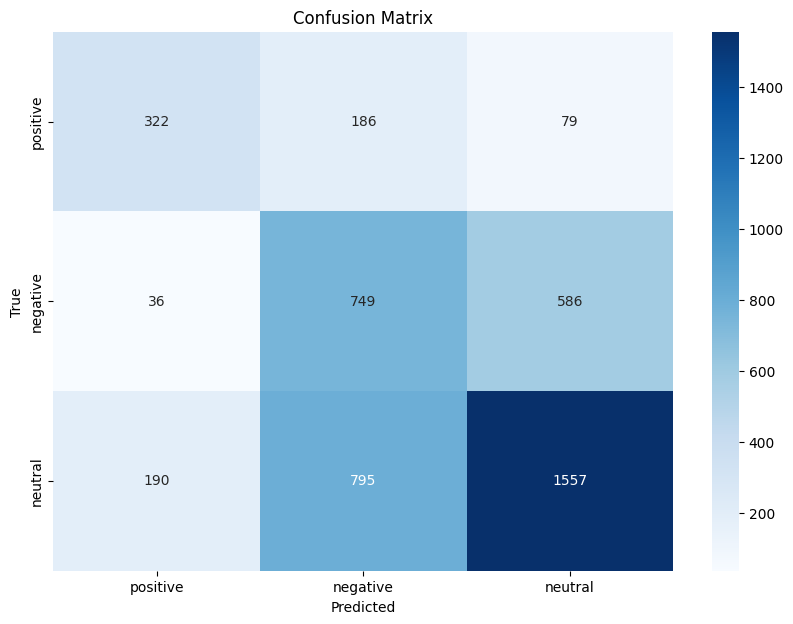

In [30]:
conf_matrix_pip_model = confusion_matrix(y_true = senti_df['sentiment'], y_pred = senti_df['sentiment_pred_pip_model'],labels=['positive','negative','neutral'])
# plot confusion matrix
plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix_pip_model, annot=True, fmt='d', cmap='Blues', xticklabels=['positive','negative','neutral'], yticklabels=['positive','negative','neutral'])
#sns.heatmap(conf_matrix_bert, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [31]:
print(classification_report(senti_df['sentiment'], senti_df['sentiment_pred_pip_model'], target_names=['negative', 'neutral', 'positive']))

              precision    recall  f1-score   support

    negative       0.43      0.55      0.48      1371
     neutral       0.70      0.61      0.65      2542
    positive       0.59      0.55      0.57       587

    accuracy                           0.58      4500
   macro avg       0.57      0.57      0.57      4500
weighted avg       0.60      0.58      0.59      4500



# Das Gleiche Modell direkt über die Transformers-Bibliothek

Zuerst laden wir das Modell und den passenden Tokenizer über den Namen...

In [33]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

device = 'cuda'

model_name_guhr = "oliverguhr/german-sentiment-bert"
model_guhr_hf = AutoModelForSequenceClassification.from_pretrained(model_name_guhr, num_labels=3).to(device)
tokenizer_guhr_hf = AutoTokenizer.from_pretrained(model_name_guhr)

c:\ProgFiles\PythonVenvs\nlpvenv2\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Das Klassifizieren von Beispielen zeigt, dass das Mapping von Label auf ID anders ist, als das, welches wir beim Labeln genutzt haben.

In [34]:

texts = ["Ich finde das doof!",
         "Quatsch",
         "Ich liebe diesen Stuhl!",
         "<3",
         "Das Essen war super lecker",
         "Er ging in den Laden",
         "Dann kaufte er einen Rechen"]


inputs = tokenizer_guhr_hf(texts, padding=True, truncation=True, return_tensors="pt").to(device)


with torch.no_grad():
    outputs = model_guhr_hf(**inputs)

logits = outputs.logits.to('cpu')

predictions = np.argmax(logits.numpy(), axis=-1)
for i, pred in enumerate(predictions):
    print(f"{texts[i]} -> {pred}")

Ich finde das doof! -> 1
Quatsch -> 1
Ich liebe diesen Stuhl! -> 0
<3 -> 0
Das Essen war super lecker -> 0
Er ging in den Laden -> 2
Dann kaufte er einen Rechen -> 2


Deswegen müssen wir das Ganze umwandeln...

In [8]:
id2label_guhr = {0:'positive',1:'negative', 2:'neutral'}
label2id_guhr = {v: k for k, v in id2label_guhr.items()}
print(label2id_guhr)
senti_df['sentiment_id'] = senti_df['sentiment'].map(label2id_guhr)
senti_df.head()

{'positive': 0, 'negative': 1, 'neutral': 2}


,sentiment,text,sentiment_predicted_aari_model,sentiment_id
0,negative,Weiß das das Jugendamt?,2,1
1,neutral,Wieso?,2,2
2,neutral,Erasmus,1,2
3,positive,Sehr richtig!,0,0
4,negative,Sie aber auch nicht!,2,1


Implementieren einer Batch-Predict-Funktion für das direkt von Huggingface gezogene Modell.

In [36]:
def prediction_batches_guhr_hf(texts):
    def chunks(lst, n):
        """Yield successive n-sized chunks from lst."""
        for i in range(0, len(lst), n):
            yield lst[i:i + n]
    pred = []
    
    for batch in chunks(texts, 500):
        inputs = tokenizer_guhr_hf(batch, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model_guhr_hf(**inputs)
        logits = outputs.logits.to('cpu')
        curr_preds = np.argmax(logits.numpy(), axis=-1)
        pred.extend(curr_preds)
        torch.cuda.empty_cache()

    return pred

prediction_batches_guhr_hf(["Ich finde das doof!",
         "Quatsch",
         "Ich liebe diesen Stuhl!",
         "<3",
         "Das Essen war super lecker",
         "Er ging in den Laden",
         "Dann kaufte er einen Rechen"])


[1, 1, 0, 0, 0, 2, 2]

In [37]:
senti_df['sentiment_id_predicted_hf_model'] = prediction_batches_guhr_hf(senti_df['text'].to_list())

In [38]:
senti_df.head()

,sentiment,text,sentiment_predicted_aari_model,sentiment_pred_pip_model,sentiment_id,sentiment_id_predicted_hf_model
0,negative,Weiß das das Jugendamt?,2,neutral,1,2
1,neutral,Wieso?,2,negative,2,1
2,neutral,Erasmus,1,negative,2,1
3,positive,Sehr richtig!,0,positive,0,0
4,negative,Sie aber auch nicht!,2,neutral,1,1


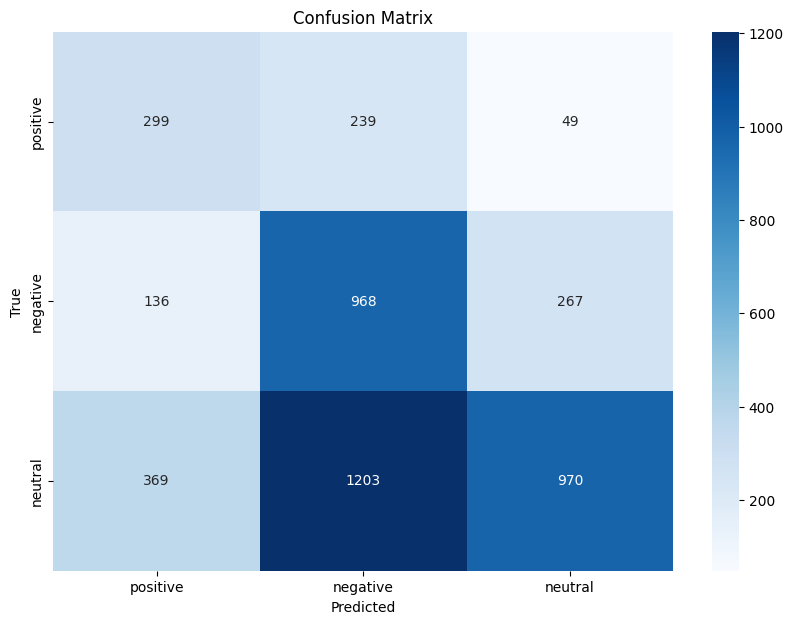

In [39]:

conf_matrix_bert = confusion_matrix(y_true = senti_df['sentiment_id'], y_pred = senti_df['sentiment_id_predicted_hf_model'])

plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix_bert, annot=True, fmt='d', cmap='Blues', xticklabels=['positive','negative','neutral'], yticklabels=['positive','negative','neutral'])
#sns.heatmap(conf_matrix_bert, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [40]:
print(classification_report(senti_df['sentiment_id'], senti_df['sentiment_id_predicted_hf_model'], target_names=['positive', 'negative', 'neutral']))

              precision    recall  f1-score   support

    positive       0.37      0.51      0.43       587
    negative       0.40      0.71      0.51      1371
     neutral       0.75      0.38      0.51      2542

    accuracy                           0.50      4500
   macro avg       0.51      0.53      0.48      4500
weighted avg       0.60      0.50      0.50      4500



Wie man klar erkennen kann, funktioniert das Modell so deutlich schlechter. Aber woran liegt das?  
Es wurde zwar der richtige Tokenizer genutzt, aber es fehlen weitere Vorverarbeitungsschritte. Diese können im [Github des Pip-Moduls](https://github.com/oliverguhr/german-sentiment-lib/tree/master) gefunden werden.  
 
Die Folgende Klasse ist eine leicht abgeänderte Version der Klasse, die per Pip-Modul erhältlich ist und enthält die nötigen Vorverarbeitungsschritte.  
Zusätzlich habe ich auch noch wie in den oberen beiden Beispielen Batch-Verarbeitung eingebaut. Im Vergleich lief das Modell mit Batch-Verarbeitung bei mir auch fast 10 mal schneller, weil der VRAM nicht immer fast gänzlich ausgelastet war.

In [34]:
class SentimentModelGuhr():
    def __init__(self, model_name: str = "oliverguhr/german-sentiment-bert"):
        if torch.cuda.is_available():
            self.device = 'cuda'
        else:
            self.device = 'cpu'        
        

        self.model = AutoModelForSequenceClassification.from_pretrained(model_name)
        print('loaded standard model')
        self.model = self.model.to(self.device)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        self.clean_chars = re.compile(r'[^A-Za-züöäÖÜÄß ]', re.MULTILINE)
        self.clean_http_urls = re.compile(r'https*\S+', re.MULTILINE)
        self.clean_at_mentions = re.compile(r'@\S+', re.MULTILINE)

    def predict_sentiment_batches(self, texts, output_probabilities = False):
        texts = [self.clean_text(text) for text in texts]

        def chunks(lst, n):
            """Yield successive n-sized chunks from lst."""
            for i in range(0, len(lst), n):
                yield lst[i:i + n]
        
        label_ids =[]
        probabilities = []

        for batch in chunks(texts, 500):
            print(f'starting batch of {len(batch)}')
            encoded = self.tokenizer.batch_encode_plus(batch,padding=True, add_special_tokens=True,truncation=True, return_tensors="pt")
            encoded = encoded.to(self.device)
            with torch.no_grad():
                    logits = self.model(**encoded)
            
            curr_label_ids = torch.argmax(logits[0], axis=1)
            label_ids.extend(curr_label_ids)

            if output_probabilities:
                predictions = torch.softmax(logits[0], dim=-1).tolist()  
                curr_probabilities = []
                for prediction in predictions:
                    curr_probabilities += [[[self.model.config.id2label[index], item] for index, item in enumerate(prediction)]]
                probabilities.extend(curr_probabilities)
            torch.cuda.empty_cache()

        if output_probabilities:
            return [self.model.config.id2label[label_id.item()] for label_id in label_ids], probabilities
        
        return [self.model.config.id2label[label_id.item()] for label_id in label_ids]
    
    def replace_numbers(self,text: str) -> str:
            return text.replace("0"," null").replace("1"," eins").replace("2"," zwei")\
                .replace("3"," drei").replace("4"," vier").replace("5"," fünf") \
                .replace("6"," sechs").replace("7"," sieben").replace("8"," acht") \
                .replace("9"," neun")         

    def clean_text(self,text: str)-> str:    
            text = text.replace("\n", " ")        
            text = self.clean_http_urls.sub('',text)
            text = self.clean_at_mentions.sub('',text)        
            text = self.replace_numbers(text)                
            text = self.clean_chars.sub('', text) # use only text chars                          
            text = ' '.join(text.split()) # substitute multiple whitespace with single whitespace   
            text = text.strip().lower()
            return text

In [32]:
senti_model = SentimentModelGuhr()

loaded standard model


In [22]:
import torch
torch.cuda.empty_cache()

In [35]:
senti_df['sentiment_pred_hf_model_cleaned'] = senti_model.predict_sentiment_batches(senti_df['text'])

starting batch of 500
starting batch of 500
starting batch of 500
starting batch of 500
starting batch of 500
starting batch of 500
starting batch of 500
starting batch of 500
starting batch of 500


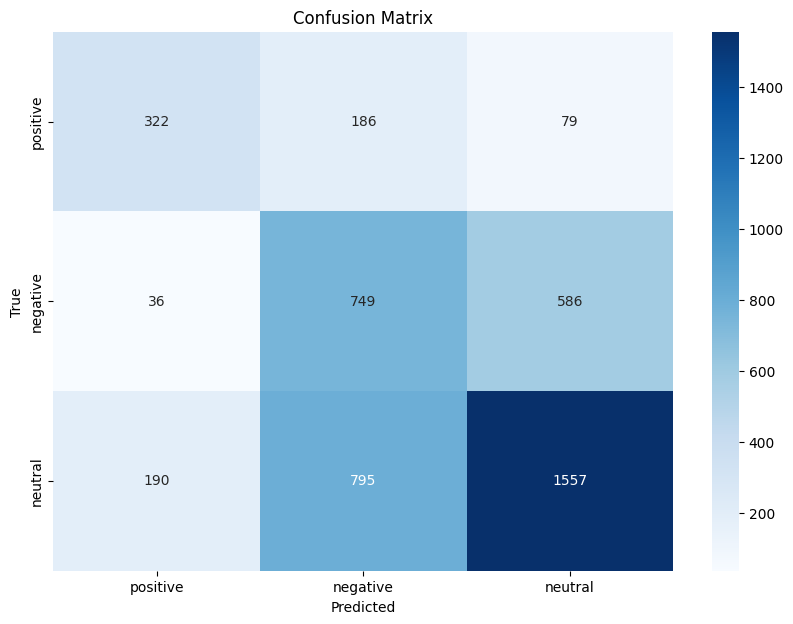

In [37]:
conf_matrix_pip_model = confusion_matrix(y_true = senti_df['sentiment'], y_pred = senti_df['sentiment_pred_hf_model_cleaned'],labels=['positive','negative','neutral'])
# plot confusion matrix
plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix_pip_model, annot=True, fmt='d', cmap='Blues', xticklabels=['positive','negative','neutral'], yticklabels=['positive','negative','neutral'])
#sns.heatmap(conf_matrix_bert, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

So, jetzt funktioniert das Modell endlich so, wie wir es brauchen.  
Die Notwendigkeit der speziellen Vorverarbeitung erklärt auch, warum die Performance in meinem ersten Finetuning-Versuch einfach nicht besser werden wollte.  
Ich habe das Modell dort für ca. eine Stunde auf dem von mir gelabelten Datenteil trainiert (nur 1000 Zwischenrufe).
Dabei ist die Accuracy in jeder Epoche random um den Wert 0.65 herumgesprungen, während der eval-loss immer größer wurde. Das Notebook findet man [hier](./referenced_notebooks/05_sentiment_analysis.ipynb)

## Aari1995 German_Sentiment

Ein anderes Modell, das ich in Erwägung gezogen habe, ist von Aari1995.  
[Das Modell](https://huggingface.co/aari1995/German_Sentiment) basiert auf gBERT-large von der (auch aus der Vorlesung bekannten) Firma deepset und wurde auf Twitter-Daten finegetuned.  
Unsere Zwischenrufe sind zwar nicht auf 280 Zeilen beschränkt, jedoch trotzdem vergleichsweise kurz und voll mit Meinungen jeder Art.  

In [4]:
model_name_aari = "aari1995/German_Sentiment"
model_aari = AutoModelForSequenceClassification.from_pretrained(model_name_aari, num_labels=3)
tokenizer_aari = AutoTokenizer.from_pretrained(model_name_aari)

c:\ProgFiles\PythonVenvs\nlpvenv2\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\ProgFiles\PythonVenvs\nlpvenv2\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [9]:
def prediction_aari(texts, batches = False, batch_size = 500):

    model_aari.to(device)
    predictions = []
    
    # batch processing necessary for my gpu with only 6gb VRAM
    if batches:

        def chunks(lst, n):
            """Yield successive n-sized chunks from lst."""
            for i in range(0, len(lst), n):
                yield lst[i:i + n]
        
        for batch in chunks(texts, batch_size):
            # tokenize
            inputs = tokenizer_aari(batch, padding=True, truncation=True, return_tensors="pt").to(device)

            with torch.no_grad():
                outputs = model_aari(**inputs)

            logits = outputs.logits.to('cpu')

            # logits to predicted class
            predictions.extend(np.argmax(logits.numpy(), axis=-1).tolist())
            torch.cuda.empty_cache()
        
        
        return predictions
    else:
        # tokenize the input texts
        inputs = tokenizer_aari(texts, padding=True, truncation=True, return_tensors="pt").to(device)


        with torch.no_grad():
            outputs = model_aari(**inputs)

        logits = outputs.logits.to('cpu')

        predictions = np.argmax(logits.numpy(), axis=-1)

        return predictions


In [42]:
prediction_aari([
         "Ich finde das doof!",
         "Noch ein total negativer Satz, total traurig!",
         "Quatsch",
         "Ich liebe diesen Stuhl!",
         "<3",
         "Das Essen war super lecker",
         "Das hier ist ein Fisch",
         "Er ging in den Laden",
         "Dann kaufte er einen Rechen"])

array([2, 2, 2, 0, 0, 0, 1, 1, 1], dtype=int64)

In [5]:
if True:
    senti_df['sentiment_predicted_aari_model'] = prediction_aari(senti_df['text'].to_list(), batches = True)

In [6]:
senti_df.head()

,sentiment,text,sentiment_predicted_aari_model
0,negative,Weiß das das Jugendamt?,2
1,neutral,Wieso?,2
2,neutral,Erasmus,1
3,positive,Sehr richtig!,0
4,negative,Sie aber auch nicht!,2


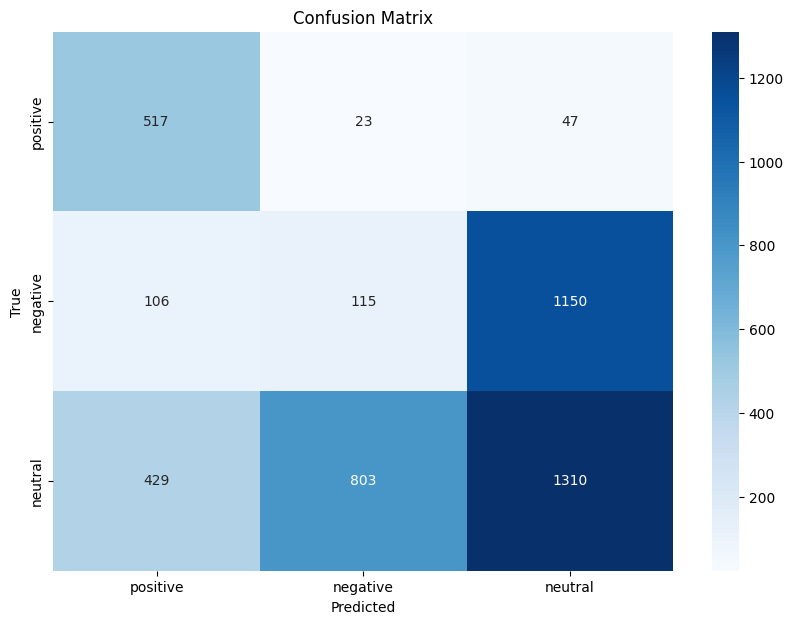

In [10]:

conf_matrix_aari_model = confusion_matrix(y_true = senti_df['sentiment_id'], y_pred = senti_df['sentiment_predicted_aari_model'])
# plot confusion matrix
plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix_aari_model, annot=True, fmt='d', cmap='Blues', xticklabels=['positive','negative','neutral'], yticklabels=['positive','negative','neutral'])
#sns.heatmap(conf_matrix_bert, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [11]:
print(classification_report(senti_df['sentiment_id'], senti_df['sentiment_predicted_aari_model'], target_names=['positive', 'negative', 'neutral']))

              precision    recall  f1-score   support

    positive       0.49      0.88      0.63       587
    negative       0.12      0.08      0.10      1371
     neutral       0.52      0.52      0.52      2542

    accuracy                           0.43      4500
   macro avg       0.38      0.49      0.42      4500
weighted avg       0.40      0.43      0.41      4500



Leider sind die Ergebnisse nochmal deutlich schlechter, als beim Modell von Oliver Guhr.  
Vor allem die negativ-Klasse wird fast nie richtig zugeordnet und hat unfassbar schlechte precision und recall-Scores.  
Interessant ist aber, dass sich beide Modelle bei der Unterscheidung zwischen Neutral und Negativ am schwersten tun. Ganz ähnlich, wie das bei uns im Label-Prozess auch war.

Die Annahme, dass Zwischenrufe und Tweets sich in gewisser Weise ähneln könnten, trifft wohl zumindest im Sinne der Sentiment-Analyse nicht ganz zu.

Deswegen wird im Folgenden das Modell von Oliver Guhr weitertrainiert.

# Fine Tuning von Oliver Guhrs German Sentiment

In [4]:
# Optional if (re)starting the Notebook from here:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
from datasets import Dataset, DatasetDict
from transformers import pipeline
import pandas as pd
import re
import logging
from tqdm import tqdm
from datetime import datetime
import os

device = 'cuda'
seed_value = 42
senti_df = pd.read_csv('../_data/interruptions_labeled.csv')[['comment_text', 'sentiment']].rename(columns={'comment_text':'text', 'sentiment':'label'})
len(senti_df)
senti_df.head()

,text,label
0,Weiß das das Jugendamt?,1
1,Wieso?,0
2,Erasmus,0
3,Sehr richtig!,2
4,Sie aber auch nicht!,1


In [11]:
model_name_guhr = "oliverguhr/german-sentiment-bert"
model_finetuning = AutoModelForSequenceClassification.from_pretrained(model_name_guhr)
tokenizer_finetuning = AutoTokenizer.from_pretrained(model_name_guhr)

Wie oben festgestellt, folgt das Modell dem Schema {0: 'positive', 1: 'negative', 2: 'neutral'}  
Wir brauchen jetzt also noch eine Abbildung, die unsere gelabelten Daten in dieses Format umwandelt.

In [5]:
id2label_guhr= {0: 'positive', 1: 'negative', 2: 'neutral'}
label2id_guhr = {v: k for k, v in id2label_guhr.items()}
convert_labels_guhr = {0:2, 1:1, 2:0}

In [6]:
senti_df['label'] = senti_df['label'].map(convert_labels_guhr)
senti_df.head()

,text,label
0,Weiß das das Jugendamt?,1
1,Wieso?,2
2,Erasmus,2
3,Sehr richtig!,0
4,Sie aber auch nicht!,1


In [8]:
train_df = senti_df.sample(frac=0.80, random_state=42)
test_df = senti_df.drop(train_df.index)  

# use small part of data for proof of concept and lower training times during trial and error
train_dataset = Dataset.from_pandas(train_df[:500], preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[:100], preserve_index=False)

dataset_dict = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

print(dataset_dict["train"][16])

{'text': 'Eine Straße ist nach ihm benannt! Hier um die Ecke! Das tut deinem Hirn gut, wenn da ein bisschen Luft reinkommt, und deinem Bauch auch!', 'label': 1}


In [6]:
clean_chars = re.compile(r'[^A-Za-züöäÖÜÄß ]', re.MULTILINE)
clean_http_urls = re.compile(r'https*\S+', re.MULTILINE)
clean_at_mentions = re.compile(r'@\S+', re.MULTILINE)

def replace_numbers(text):
        return text.replace("0"," null").replace("1"," eins").replace("2"," zwei")\
            .replace("3"," drei").replace("4"," vier").replace("5"," fünf") \
            .replace("6"," sechs").replace("7"," sieben").replace("8"," acht") \
            .replace("9"," neun")         

def clean_text(text):
        text = text.replace("\n", " ")        
        text = clean_http_urls.sub('',text)
        text = clean_at_mentions.sub('',text)        
        text = replace_numbers(text)                
        text = clean_chars.sub('', text) # use only text chars                          
        text = ' '.join(text.split()) # substitute multiple whitespace with single whitespace   
        text = text.strip().lower()
        return text

In [7]:
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 500
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 100
    })
})

In [12]:
max_length = tokenizer_finetuning.model_max_length
def tokenize_function(data):
    texts = [clean_text(text) for text in data['text']]
    encoded = tokenizer_finetuning.batch_encode_plus(
        texts,
        #padding=True,
        padding = 'max_length',
        add_special_tokens=True,
        max_length = max_length,
        truncation=True,
        return_tensors="pt"
    )
    return encoded

tokenized_dataset = dataset_dict.map(tokenize_function, batched=True)

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [9]:
train_dataset = tokenized_dataset["train"].shuffle(seed=42)
eval_dataset = tokenized_dataset["test"].shuffle(seed=42)
print(len(train_dataset))
print(len(eval_dataset))

500
100


In [10]:
# tensorboard_cell
from transformers import TrainingArguments, Trainer, TrainerCallback
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

train = False
if train:
    model_finetuning.to(device)
    current_datetime = datetime.now()
    formatted_datetime = current_datetime.strftime("%Y-%m-%d_%H-%M-%S") # make it okay to use for filenames 

    output_std = 'logs/standard/' + formatted_datetime+'/output/'
    log_std = 'logs/standard/' + formatted_datetime +'/logs/'
    # Define the training arguments with the seed parameter
    training_args_standard = TrainingArguments(
        output_dir=output_std, 
        evaluation_strategy="steps",
        eval_steps = 30,
        num_train_epochs=4,
        seed=seed_value,  # Set the seed here
        save_strategy="steps",
        save_steps=100,
        logging_dir=log_std,  # Specify the logging directory
        logging_steps=10,  # Log every 10 steps
        logging_strategy='steps', 
        report_to = 'tensorboard'
    )

    

def compute_metrics(p):    
    pred, labels = p
    pred = np.argmax(pred, axis=1)
    accuracy = accuracy_score(y_true=labels, y_pred=pred)
    recall = recall_score(y_true=labels, y_pred=pred, average='weighted')
    precision = precision_score(y_true=labels, y_pred=pred, average='weighted')
    f1 = f1_score(y_true=labels, y_pred=pred, average='weighted')

    # compute class-specific precision only for the classes that matter to us
    # those are positive and negative. 
    prec_pos = precision_score(y_true=labels, y_pred=pred, labels=[0], average=None)
    prec_neg = precision_score(y_true=labels, y_pred=pred, labels=[1], average=None)

    mean_prec = ((prec_pos + prec_neg) / 2)[0]
    # using weighted to take class imbalance into account
    return {"accuracy": accuracy, "precision": precision, "precision_pos_neg": mean_prec, "recall": recall, "f1": f1}

In [11]:

class LoggingCallback(TrainerCallback):

    def __init__(self, logdir):
        super().__init__()
        self.logfiles_prefix = logdir
        self.log_counter = 0
        self.eval_counter = 0

    
    def on_log(self, args, state, control, logs=None, **kwargs):
        if self.log_counter == 0:
            with open(f"{self.logfiles_prefix}/train_loss.txt", "w") as f:
                f.write(f"step,train_loss\n")
        
        if logs is not None and "loss" in logs:
            with open(f"{self.logfiles_prefix}/train_loss.txt", "a") as f:
                f.write(f"{state.global_step},{logs['loss']}\n")
        self.log_counter +=1
            
                   
    def on_evaluate(self, args, state, control, **kwargs):
        if self.eval_counter == 0:
            with open(f"{self.logfiles_prefix}/eval_metrics.txt", "w") as f:
                f.write(f"step,eval_loss,eval_accuracy,epoch\n")

        logs = kwargs.get('metrics',{})
        if logs:
            with open(f"{self.logfiles_prefix}/eval_metrics.txt", "a") as f:
                f.write(f"{state.global_step},{logs['eval_loss']},{logs['eval_accuracy']},{logs['epoch']}\n")
        self.eval_counter +=1



In [12]:
if train:
    trainer_standard = Trainer(
        model=model_finetuning,
        args=training_args_standard,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=compute_metrics,
        callbacks=[LoggingCallback(output_std)]
    )

In [13]:
if train:
# Train the model
    trainer_standard.train()

### Tensorboard to monitor loss on eval and train dataset during training

In [14]:

#%load_ext tensorboard
%load_ext tensorboard

%tensorboard --logdir ./logs/

Reusing TensorBoard on port 6006 (pid 19148), started 0:16:08 ago. (Use '!kill 19148' to kill it.)

In [15]:
#model_path_standard = "models/guhr_bert_finetuned_standard_4ep/"
#trainer_standard.save_model(model_path_standard)

Der Versuch, mit einem kleinen Teil der Daten erstmal ein Proof of Concept zu generieren, hat die ersten Probleme aufgezeigt.  
Das BERT-Modell overfittet unfassbar schnell auf die Trainingsdaten. Schon nach der zweiten Epoche ist der Loss auf dem Eval-Datensatz merkbar höher, als der auf dem Trainingsdaten.  
Wenn das Modell jetzt im Folgenden mehr Daten trainiert wird, dann verzögert sich das Problem, es wird aber vermutlich wieder auftreten.  
Deswegen habe ich mich dafür entschieden Early Stopping einzubauen, um das finale Modell zu trainieren.

In [16]:
# TODO Neu trainieren lassen und aus CSV-Logs plotten

## Finetuning mit Early Stopping

In [9]:
train_dataset = Dataset.from_pandas(train_df, preserve_index=False) # the whole dataset we have labeled
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

dataset_dict = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

tokenized_dataset = dataset_dict.map(tokenize_function, batched=True)

train_dataset = tokenized_dataset["train"].shuffle(seed=42)
eval_dataset = tokenized_dataset["test"].shuffle(seed=42)
print(len(train_dataset))
print(len(eval_dataset))

NameError: name 'tokenize_function' is not defined

In [18]:

current_datetime = datetime.now()
formatted_datetime = current_datetime.strftime("%Y-%m-%d_%H-%M-%S") # make it okay to use for filenames 

output_finetuning = 'logs/earlyst/' + formatted_datetime+'/output/'
log_finetuning = 'logs/earlyst/' + formatted_datetime +'/logs/'
training_args_standard = TrainingArguments(
    output_dir=output_finetuning, 
    evaluation_strategy="steps",
    eval_steps = 30,
    num_train_epochs=8,
    seed=seed_value, 
    save_strategy="steps",
    save_steps=30,
    logging_dir=log_finetuning,  
    logging_steps=10,  # log every 10 steps
    logging_strategy='steps', 
    report_to = 'tensorboard',
    save_total_limit = 10,
    metric_for_best_model = 'eval_loss',
    greater_is_better=False, 
    load_best_model_at_end=True,
    per_device_eval_batch_size= 24,
    per_device_train_batch_size= 24
)


c:\ProgFiles\PythonVenvs\.NLPvenv\Lib\site-packages\transformers\training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [19]:
from transformers import EarlyStoppingCallback
trainer_finetuning = Trainer(
    model=model_finetuning,
    args=training_args_standard,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=5), LoggingCallback(output_finetuning)]
)

In [20]:
train = True
if train:
    trainer_finetuning.train()  

  0%|          | 0/1200 [00:00<?, ?it/s]

c:\ProgFiles\PythonVenvs\.NLPvenv\Lib\site-packages\transformers\models\bert\modeling_bert.py:435: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


{'loss': 1.2514, 'grad_norm': 13.467867851257324, 'learning_rate': 4.958333333333334e-05, 'epoch': 0.07}
{'loss': 0.6346, 'grad_norm': 5.308777332305908, 'learning_rate': 4.9166666666666665e-05, 'epoch': 0.13}
{'loss': 0.6923, 'grad_norm': 8.498133659362793, 'learning_rate': 4.875e-05, 'epoch': 0.2}


  0%|          | 0/38 [00:00<?, ?it/s]

{'eval_loss': 0.7369009256362915, 'eval_accuracy': 0.7155555555555555, 'eval_precision': 0.7227162728285514, 'eval_precision_pos_neg': 0.6997269116186693, 'eval_recall': 0.7155555555555555, 'eval_f1': 0.7010961344873065, 'eval_runtime': 22.6309, 'eval_samples_per_second': 39.769, 'eval_steps_per_second': 1.679, 'epoch': 0.2}
{'loss': 0.6022, 'grad_norm': 4.00246000289917, 'learning_rate': 4.8333333333333334e-05, 'epoch': 0.27}
{'loss': 0.6042, 'grad_norm': 3.727978229522705, 'learning_rate': 4.791666666666667e-05, 'epoch': 0.33}
{'loss': 0.6248, 'grad_norm': 5.448042869567871, 'learning_rate': 4.75e-05, 'epoch': 0.4}


...

{'eval_loss': 0.6477572917938232, 'eval_accuracy': 0.7577777777777778, 'eval_precision': 0.755257539367706, 'eval_precision_pos_neg': 0.7379551820728292, 'eval_recall': 0.7577777777777778, 'eval_f1': 0.7558804341770502, 'eval_runtime': 20.5977, 'eval_samples_per_second': 43.694, 'eval_steps_per_second': 1.845, 'epoch': 1.6}
{'loss': 0.3454, 'grad_norm': 7.734441757202148, 'learning_rate': 3.958333333333333e-05, 'epoch': 1.67}
{'loss': 0.4175, 'grad_norm': 12.098886489868164, 'learning_rate': 3.9166666666666665e-05, 'epoch': 1.73}
{'loss': 0.4269, 'grad_norm': 8.133739471435547, 'learning_rate': 3.875e-05, 'epoch': 1.8}


  0%|          | 0/38 [00:00<?, ?it/s]

{'eval_loss': 0.665368378162384, 'eval_accuracy': 0.7533333333333333, 'eval_precision': 0.7521406849358555, 'eval_precision_pos_neg': 0.767720717408179, 'eval_recall': 0.7533333333333333, 'eval_f1': 0.7450307636859944, 'eval_runtime': 20.6149, 'eval_samples_per_second': 43.658, 'eval_steps_per_second': 1.843, 'epoch': 1.8}
{'loss': 0.3792, 'grad_norm': 4.489762306213379, 'learning_rate': 3.8333333333333334e-05, 'epoch': 1.87}
{'loss': 0.4208, 'grad_norm': 7.393604278564453, 'learning_rate': 3.791666666666667e-05, 'epoch': 1.93}
{'loss': 0.4635, 'grad_norm': 7.535828113555908, 'learning_rate': 3.7500000000000003e-05, 'epoch': 2.0}


  0%|          | 0/38 [00:00<?, ?it/s]

{'eval_loss': 0.6431262493133545, 'eval_accuracy': 0.7633333333333333, 'eval_precision': 0.7613544857189545, 'eval_precision_pos_neg': 0.7757168251024036, 'eval_recall': 0.7633333333333333, 'eval_f1': 0.758898303516164, 'eval_runtime': 20.6082, 'eval_samples_per_second': 43.672, 'eval_steps_per_second': 1.844, 'epoch': 2.0}
{'train_runtime': 4189.0494, 'train_samples_per_second': 6.875, 'train_steps_per_second': 0.286, 'train_loss': 0.5293156901995341, 'epoch': 2.0}


Ich habe einige unterschiedliche Trainingsparameter ausprobiert. 
Standard mit Batch-Größe 8, early stopping auf eval_accuracy, eval loss
Batch-Größe 16
Batch Größe 32 -> ging auf meiner Hardware nicht

In [21]:
trainer_finetuning.save_model('./models/guhr_bert_finetuned_early_stop_eval_loss_b24')  

In [22]:
err

NameError: name 'err' is not defined

# Vor + Nachteile bei Scores irgendwie beschreiben

# Bemerkung: zu lange Trainingszeit:

Übertraining schon ab Schritt 200-300. 

# Andere Loss-Funktionen

In [1]:
# Optional if (re)starting the Notebook from here:
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, TrainerCallback, AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
from datasets import Dataset, DatasetDict
from transformers import pipeline
import pandas as pd
import re
import logging
from tqdm import tqdm
from datetime import datetime
import os
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

device = 'cuda'
seed_value = 42
senti_df = pd.read_csv('../_data/interruptions_labeled.csv')[['comment_text', 'sentiment']].rename(columns={'comment_text':'text', 'sentiment':'label'})
len(senti_df)
senti_df.head()

,text,label
0,Weiß das das Jugendamt?,1
1,Wieso?,0
2,Erasmus,0
3,Sehr richtig!,2
4,Sie aber auch nicht!,1


In [2]:
model_name_guhr = "oliverguhr/german-sentiment-bert"
model_finetuning = AutoModelForSequenceClassification.from_pretrained(model_name_guhr)
tokenizer_finetuning = AutoTokenizer.from_pretrained(model_name_guhr)

In [3]:
id2label_guhr= {0: 'positive', 1: 'negative', 2: 'neutral'}
label2id_guhr = {v: k for k, v in id2label_guhr.items()}
convert_labels_guhr = {0:2, 1:1, 2:0}

In [4]:
senti_df['label'] = senti_df['label'].map(convert_labels_guhr)
senti_df.head()

,text,label
0,Weiß das das Jugendamt?,1
1,Wieso?,2
2,Erasmus,2
3,Sehr richtig!,0
4,Sie aber auch nicht!,1


In [5]:
clean_chars = re.compile(r'[^A-Za-züöäÖÜÄß ]', re.MULTILINE)
clean_http_urls = re.compile(r'https*\S+', re.MULTILINE)
clean_at_mentions = re.compile(r'@\S+', re.MULTILINE)

def replace_numbers(text):
        return text.replace("0"," null").replace("1"," eins").replace("2"," zwei")\
            .replace("3"," drei").replace("4"," vier").replace("5"," fünf") \
            .replace("6"," sechs").replace("7"," sieben").replace("8"," acht") \
            .replace("9"," neun")         

def clean_text(text):
        text = text.replace("\n", " ")        
        text = clean_http_urls.sub('',text)
        text = clean_at_mentions.sub('',text)        
        text = replace_numbers(text)                
        text = clean_chars.sub('', text) # use only text chars                          
        text = ' '.join(text.split()) # substitute multiple whitespace with single whitespace   
        text = text.strip().lower()
        return text

In [6]:
max_length = tokenizer_finetuning.model_max_length
def tokenize_function(data):
    texts = [clean_text(text) for text in data['text']]
    encoded = tokenizer_finetuning.batch_encode_plus(
        texts,
        #padding=True,
        padding = 'max_length',
        add_special_tokens=True,
        max_length = max_length,
        truncation=True,
        return_tensors="pt"
    )
    return encoded

In [7]:
train_df = senti_df.sample(frac=0.80, random_state=42)
test_df = senti_df.drop(train_df.index)  

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

dataset_dict = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

tokenized_dataset = dataset_dict.map(tokenize_function, batched=True)

train_dataset = tokenized_dataset["train"].shuffle(seed=42)
eval_dataset = tokenized_dataset["test"].shuffle(seed=42)
print(len(train_dataset))
print(len(eval_dataset))

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

3600
900


In [8]:
def compute_metrics(p):    
    pred, labels = p
    pred = np.argmax(pred, axis=1)
    accuracy = accuracy_score(y_true=labels, y_pred=pred)
    recall = recall_score(y_true=labels, y_pred=pred, average='weighted')
    precision = precision_score(y_true=labels, y_pred=pred, average='weighted')
    f1 = f1_score(y_true=labels, y_pred=pred, average='weighted')

    # compute class-specific precision only for the classes that matter to us
    # those are positive and negative. 
    prec_pos = precision_score(y_true=labels, y_pred=pred, labels=[0], average=None)
    prec_neg = precision_score(y_true=labels, y_pred=pred, labels=[1], average=None)

    mean_prec = ((prec_pos + prec_neg) / 2)[0]
    # using weighted to take class imbalance into account
    return {"accuracy": accuracy, "precision": precision, "precision_pos_neg": mean_prec, "recall": recall, "f1": f1}

In [9]:
class LoggingCallback(TrainerCallback):

    def __init__(self, logdir):
        super().__init__()
        self.logfiles_prefix = logdir
        self.log_counter = 0
        self.eval_counter = 0

    
    def on_log(self, args, state, control, logs=None, **kwargs):
        if self.log_counter == 0:
            with open(f"{self.logfiles_prefix}/train_loss.txt", "w") as f:
                f.write(f"step,train_loss\n")
        
        if logs is not None and "loss" in logs:
            with open(f"{self.logfiles_prefix}/train_loss.txt", "a") as f:
                f.write(f"{state.global_step},{logs['loss']}\n")
        self.log_counter +=1
            
                   
    def on_evaluate(self, args, state, control, **kwargs):
        if self.eval_counter == 0:
            with open(f"{self.logfiles_prefix}/eval_metrics.txt", "w") as f:
                f.write(f"step,eval_loss,eval_accuracy,epoch\n")

        logs = kwargs.get('metrics',{})
        if logs:
            with open(f"{self.logfiles_prefix}/eval_metrics.txt", "a") as f:
                f.write(f"{state.global_step},{logs['eval_loss']},{logs['eval_accuracy']},{logs['epoch']}\n")
        self.eval_counter +=1



In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.CrossEntropyLoss()(inputs, targets)
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        else:
            return F_loss

In [11]:
class CustomTrainer(Trainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.criterion = FocalLoss()

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss = self.criterion(logits, labels)
        return (loss, outputs) if return_outputs else loss


In [12]:
current_datetime = datetime.now()
formatted_datetime = current_datetime.strftime("%Y-%m-%d_%H-%M-%S") # make it okay to use for filenames 

output_finetuning = 'logs/focal/' + formatted_datetime+'/output/'
log_finetuning = 'logs/focal/' + formatted_datetime +'/logs/'


training_args_focal = TrainingArguments(
    output_dir=output_finetuning, 
    evaluation_strategy="steps",
    eval_steps = 20,
    num_train_epochs=8,
    seed=seed_value, 
    save_strategy="steps",
    save_steps=20,
    logging_dir=log_finetuning,  
    logging_steps=10,  # log every 10 steps
    logging_strategy='steps', 
    report_to = 'tensorboard',
    save_total_limit = 10,
    metric_for_best_model = 'eval_loss',
    greater_is_better=False, 
    load_best_model_at_end=True,
    per_device_eval_batch_size= 24,
    per_device_train_batch_size= 24
)

c:\ProgFiles\PythonVenvs\.NLPvenv\Lib\site-packages\transformers\training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [13]:
from transformers import EarlyStoppingCallback
trainer_finetuning = CustomTrainer(
    model=model_finetuning,
    args=training_args_focal,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=5), LoggingCallback(output_finetuning)]
)

In [14]:
train = True
if train:
    trainer_finetuning.train()  

  0%|          | 0/1200 [00:00<?, ?it/s]

c:\ProgFiles\PythonVenvs\.NLPvenv\Lib\site-packages\transformers\models\bert\modeling_bert.py:435: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


{'loss': 0.6841, 'grad_norm': 8.75127124786377, 'learning_rate': 4.958333333333334e-05, 'epoch': 0.07}
{'loss': 0.1454, 'grad_norm': 2.2241227626800537, 'learning_rate': 4.9166666666666665e-05, 'epoch': 0.13}


  0%|          | 0/38 [00:00<?, ?it/s]

{'eval_loss': 0.20665708184242249, 'eval_accuracy': 0.6966666666666667, 'eval_precision': 0.6909076161453842, 'eval_precision_pos_neg': 0.6742927221211993, 'eval_recall': 0.6966666666666667, 'eval_f1': 0.6894533103646283, 'eval_runtime': 20.5227, 'eval_samples_per_second': 43.854, 'eval_steps_per_second': 1.852, 'epoch': 0.13}
{'loss': 0.1868, 'grad_norm': 3.59041166305542, 'learning_rate': 4.875e-05, 'epoch': 0.2}
{'loss': 0.1367, 'grad_norm': 1.907149314880371, 'learning_rate': 4.8333333333333334e-05, 'epoch': 0.27}


...

{'eval_loss': 0.1463586837053299, 'eval_accuracy': 0.7633333333333333, 'eval_precision': 0.781577974976786, 'eval_precision_pos_neg': 0.8348618527977711, 'eval_recall': 0.7633333333333333, 'eval_f1': 0.7463369427372939, 'eval_runtime': 20.7214, 'eval_samples_per_second': 43.433, 'eval_steps_per_second': 1.834, 'epoch': 1.33}
{'loss': 0.0442, 'grad_norm': 3.3784286975860596, 'learning_rate': 4.125e-05, 'epoch': 1.4}
{'loss': 0.0615, 'grad_norm': 2.287179708480835, 'learning_rate': 4.0833333333333334e-05, 'epoch': 1.47}


  0%|          | 0/38 [00:00<?, ?it/s]

{'eval_loss': 0.13981497287750244, 'eval_accuracy': 0.7677777777777778, 'eval_precision': 0.7672242532622566, 'eval_precision_pos_neg': 0.7955164466792374, 'eval_recall': 0.7677777777777778, 'eval_f1': 0.761992643818536, 'eval_runtime': 20.7678, 'eval_samples_per_second': 43.336, 'eval_steps_per_second': 1.83, 'epoch': 1.47}
{'loss': 0.0536, 'grad_norm': 1.7137340307235718, 'learning_rate': 4.041666666666667e-05, 'epoch': 1.53}
{'loss': 0.0649, 'grad_norm': 4.1415252685546875, 'learning_rate': 4e-05, 'epoch': 1.6}


  0%|          | 0/38 [00:00<?, ?it/s]

{'eval_loss': 0.17352890968322754, 'eval_accuracy': 0.7511111111111111, 'eval_precision': 0.7502476295550399, 'eval_precision_pos_neg': 0.7275018315018316, 'eval_recall': 0.7511111111111111, 'eval_f1': 0.7505661881147135, 'eval_runtime': 20.587, 'eval_samples_per_second': 43.717, 'eval_steps_per_second': 1.846, 'epoch': 1.6}
{'train_runtime': 3364.1451, 'train_samples_per_second': 8.561, 'train_steps_per_second': 0.357, 'train_loss': 0.1295314262310664, 'epoch': 1.6}


In [15]:
trainer_finetuning.save_model('./models/guhr_bert_finetuned_focal_loss_early_stop_eval_loss_b8')  

## Weighted Cross Entropy Loss

In [16]:
from collections import Counter
class_counts = Counter(train_df['label'])
total_samples = len(train_df)
class_weights = {label: total_samples / count for label, count in class_counts.items()}

# Convert class weights to a tensor
class_weights_tensor = torch.tensor([class_weights[label] for label in range(len(class_counts))], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

In [17]:
trainer_finetuning = CustomTrainer(
    model=model_finetuning,
    args=training_args_standard,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=5), LoggingCallback(output_finetuning)],

)

In [18]:
train = True
if train:
    trainer_finetuning.train()

  0%|          | 0/1200 [00:00<?, ?it/s]

{'loss': 0.0524, 'grad_norm': 0.5168671607971191, 'learning_rate': 4.958333333333334e-05, 'epoch': 0.07}
{'loss': 0.0178, 'grad_norm': 0.22968435287475586, 'learning_rate': 4.9166666666666665e-05, 'epoch': 0.13}


  0%|          | 0/38 [00:00<?, ?it/s]

{'eval_loss': 0.22750838100910187, 'eval_accuracy': 0.7488888888888889, 'eval_precision': 0.7460349579575344, 'eval_precision_pos_neg': 0.7675666883539363, 'eval_recall': 0.7488888888888889, 'eval_f1': 0.742019240761589, 'eval_runtime': 239.6455, 'eval_samples_per_second': 3.756, 'eval_steps_per_second': 0.159, 'epoch': 0.13}
{'loss': 0.0412, 'grad_norm': 1.0849460363388062, 'learning_rate': 4.875e-05, 'epoch': 0.2}
{'loss': 0.0278, 'grad_norm': 0.3605464696884155, 'learning_rate': 4.8333333333333334e-05, 'epoch': 0.27}


  0%|          | 0/38 [00:00<?, ?it/s]

...

{'eval_loss': 0.2409038096666336, 'eval_accuracy': 0.7333333333333333, 'eval_precision': 0.7291136264429664, 'eval_precision_pos_neg': 0.7408041831950956, 'eval_recall': 0.7333333333333333, 'eval_f1': 0.7290792662590327, 'eval_runtime': 130.7609, 'eval_samples_per_second': 6.883, 'eval_steps_per_second': 0.291, 'epoch': 1.47}
{'loss': 0.0379, 'grad_norm': 0.9690513014793396, 'learning_rate': 4.041666666666667e-05, 'epoch': 1.53}
{'loss': 0.0256, 'grad_norm': 2.8512773513793945, 'learning_rate': 4e-05, 'epoch': 1.6}


  0%|          | 0/38 [00:00<?, ?it/s]

{'eval_loss': 0.21884939074516296, 'eval_accuracy': 0.7388888888888889, 'eval_precision': 0.7356633422114908, 'eval_precision_pos_neg': 0.7391456582633054, 'eval_recall': 0.7388888888888889, 'eval_f1': 0.7364982460244731, 'eval_runtime': 130.7629, 'eval_samples_per_second': 6.883, 'eval_steps_per_second': 0.291, 'epoch': 1.6}
{'loss': 0.0194, 'grad_norm': 0.5057199597358704, 'learning_rate': 3.958333333333333e-05, 'epoch': 1.67}
{'loss': 0.0189, 'grad_norm': 2.395340919494629, 'learning_rate': 3.9166666666666665e-05, 'epoch': 1.73}


  0%|          | 0/38 [00:00<?, ?it/s]

{'eval_loss': 0.2239629477262497, 'eval_accuracy': 0.7433333333333333, 'eval_precision': 0.741299763819385, 'eval_precision_pos_neg': 0.7427741893390749, 'eval_recall': 0.7433333333333333, 'eval_f1': 0.7419848020804657, 'eval_runtime': 130.7077, 'eval_samples_per_second': 6.886, 'eval_steps_per_second': 0.291, 'epoch': 1.73}
{'train_runtime': 5902.5009, 'train_samples_per_second': 4.879, 'train_steps_per_second': 0.203, 'train_loss': 0.034349814888376455, 'epoch': 1.73}


In [19]:
trainer_finetuning.save_model('./models/guhr_bert_finetuned_weighted_cross_entropy')

# Evaluation

In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import re
import torch

device = 'cuda'
finetuned_model_path = "models/guhr_bert_finetuned_early_stop_eval_loss_b24"
finetuned_model_path = "models/guhr_bert_finetuned_weighted_cross_entropy"
model_name_guhr = "oliverguhr/german-sentiment-bert"

loaded_model = AutoModelForSequenceClassification.from_pretrained(finetuned_model_path).to(device)
loaded_tokenizer = AutoTokenizer.from_pretrained(model_name_guhr)


clean_chars = re.compile(r'[^A-Za-züöäÖÜÄß ]', re.MULTILINE)
clean_http_urls = re.compile(r'https*\S+', re.MULTILINE)
clean_at_mentions = re.compile(r'@\S+', re.MULTILINE)

def replace_numbers(text):
    return text.replace("0"," null").replace("1"," eins").replace("2"," zwei")\
        .replace("3"," drei").replace("4"," vier").replace("5"," fünf") \
        .replace("6"," sechs").replace("7"," sieben").replace("8"," acht") \
        .replace("9"," neun")         

def clean_text(text):
    text = text.replace("\n", " ")        
    text = clean_http_urls.sub('',text)
    text = clean_at_mentions.sub('',text)        
    text = replace_numbers(text)                
    text = clean_chars.sub('', text)                       
    text = ' '.join(text.split()) 
    text = text.strip().lower()
    return text



def predict_sentiment_batches( texts):
        texts = [clean_text(text) for text in texts]

        def chunks(lst, n):
            """Yield successive n-sized chunks from lst."""
            for i in range(0, len(lst), n):
                yield lst[i:i + n]
        
        label_ids =[]

        for batch in chunks(texts, 500):
            print(f'starting batch of {len(batch)}')
            encoded = loaded_tokenizer.batch_encode_plus(batch,padding=True, add_special_tokens=True,truncation=True, return_tensors="pt")
            encoded = encoded.to(device)
            with torch.no_grad():
                    logits = loaded_model(**encoded)
            
            curr_label_ids = torch.argmax(logits[0], axis=1).to('cpu').numpy()
            label_ids.extend(curr_label_ids)

    
            torch.cuda.empty_cache()
            
        id2label = loaded_model.config.id2label
        return [id2label[label_id] for label_id in label_ids]


def predict(texts):
    texts = [clean_text(text) for text in texts]
    inputs = loaded_tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = loaded_model(**inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    id2label = loaded_model.config.id2label
    return [id2label[pred.item()] for pred in predictions]

# Example usage
texts = [
    "Mit keinem guten Ergebnis", "Das ist gar nicht mal so gut",
    "Total awesome!", "nicht so schlecht wie erwartet",
    "Der Test verlief positiv.", "Sie fährt ein grünes Auto.", 
    "Das Produkt ist so unfassbar schlecht!"
]

predictions = predict(texts)
print(predictions)

['negative', 'negative', 'positive', 'positive', 'neutral', 'neutral', 'negative']


c:\ProgFiles\PythonVenvs\.NLPvenv\Lib\site-packages\transformers\models\bert\modeling_bert.py:435: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


In [2]:
import torch
torch.cuda.empty_cache()

In [11]:
senti_df['sentiment_pred_finetuned'] = predict_sentiment_batches(senti_df['text'])

starting batch of 500
starting batch of 500
starting batch of 500
starting batch of 500
starting batch of 500
starting batch of 500
starting batch of 500
starting batch of 500
starting batch of 500


In [21]:
test_df['sentiment_pred_finetuned'] = predict_sentiment_batches(test_df['text'])
test_df['pred_finetuned_id'] = test_df['sentiment_pred_finetuned'].map(label2id_guhr)

starting batch of 500
starting batch of 400


In [ ]:
senti_df.head()

,text,label,sentiment_pred_finetuned
0,Weiß das das Jugendamt?,1,neutral
1,Wieso?,2,negative
2,Erasmus,2,negative
3,Sehr richtig!,0,positive
4,Sie aber auch nicht!,1,neutral


In [16]:
senti_df['pred_finetuned_id'] = senti_df['sentiment_pred_finetuned'].map(label2id_guhr)


In [22]:
senti_df['label'] = senti_df['label'].map(convert_labels_guhr)

In [12]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

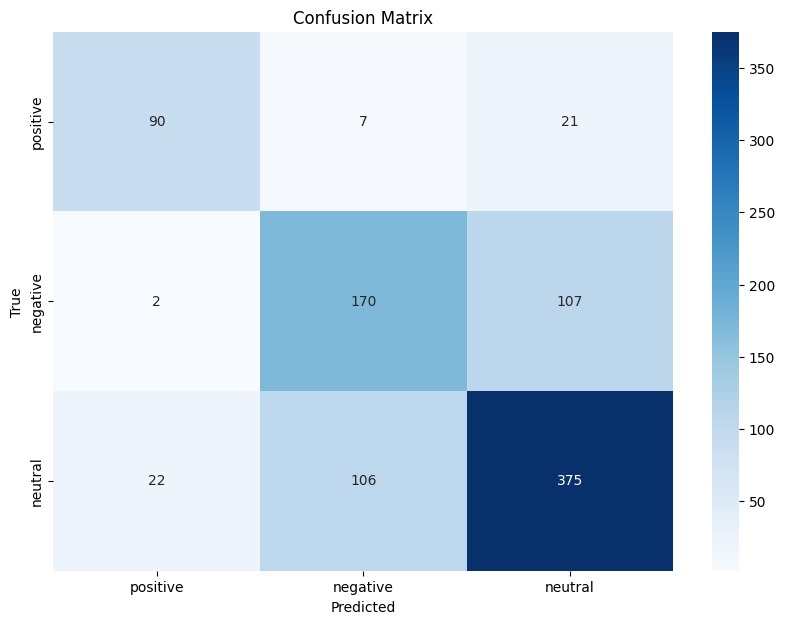

In [23]:
conf_matrix_finetuned = confusion_matrix(y_true = senti_df['label'], y_pred = senti_df['pred_finetuned_id'])
conf_matrix_finetuned = confusion_matrix(y_true = test_df['label'], y_pred = test_df['pred_finetuned_id'])

# plot confusion matrix
plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix_finetuned, annot=True, fmt='d', cmap='Blues', xticklabels=['positive','negative','neutral'], yticklabels=['positive','negative','neutral'])
#sns.heatmap(conf_matrix_bert, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [18]:
from sklearn.metrics import classification_report

In [24]:
print(classification_report(test_df['label'], test_df['pred_finetuned_id'], target_names=['positive', 'negative', 'neutral']))

              precision    recall  f1-score   support

    positive       0.79      0.76      0.78       118
    negative       0.60      0.61      0.60       279
     neutral       0.75      0.75      0.75       503

    accuracy                           0.71       900
   macro avg       0.71      0.71      0.71       900
weighted avg       0.71      0.71      0.71       900



Ich habe erst mit 3000 gelabelten Daten trainiert, dann mit 4500. Der Unterschied in der Accuracy liegt bei nur einem Prozent.  
Wenn man die 